## Import required libraries

In [3]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

2026-04-29 18:35:40.226658: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777487740.450205      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777487740.516656      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777487741.061430      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777487741.061486      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777487741.061489      57 computation_placer.cc:177] computation placer alr

In [4]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_124.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_949.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_786.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_371.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_599.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_802.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_1323.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_1347.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_955.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_778.jpg
/kaggle/input/datasets/masou

## DATA CONFIGURATION

In [5]:
data_dir = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training'
batch_size = 32
img_height = 128
img_width = 128

## LOAD TRAINING AND VALIDATION DATA

In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size
)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.


2026-04-29 18:36:42.003217: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [7]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size
)

Found 5600 files belonging to 4 classes.
Using 1120 files for validation.


## BUILD THE CNN MODEL ARCHITECTURE

In [8]:
model = models.Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  
  layers.Dense(4) 
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## COMPILE THE MODEL

In [9]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

## TRAIN THE MODEL

In [10]:
print("Starting training...")
epochs = 10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Starting training...
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 75s 527ms/step - accuracy: 0.5618 - loss: 1.1600 - val_accuracy: 0.8411 - val_loss: 0.4070
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 73s 523ms/step - accuracy: 0.8816 - loss: 0.3519 - val_accuracy: 0.8696 - val_loss: 0.3190
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 74s 527ms/step - accuracy: 0.9325 - loss: 0.1944 - val_accuracy: 0.8991 - val_loss: 0.2619
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 74s 528ms/step - accuracy: 0.9581 - loss: 0.1111 - val_accuracy: 0.9161 - val_loss: 0.2499
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 74s 526ms/step - accuracy: 0.9771 - loss: 0.0689 - val_accuracy: 0.9366 - val_loss: 0.2243
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 73s 524ms/step - accuracy: 0.9902 - loss: 0.0343 - val_accuracy: 0.9259 - val_loss: 0.2265
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 73s 523ms/step - accuracy: 0.9955 - loss: 0.0194 - val_accuracy: 0.9286 - val_loss: 0.2452
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 79s 560ms/step - accur

## Testing

In [11]:
test_dir = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing'

test_ds = tf.keras.utils.image_dataset_from_directory(
  test_dir,
  image_size=(img_height, img_width),
  batch_size=batch_size
)

test_loss, test_acc = model.evaluate(test_ds)

Found 1600 files belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 149ms/step - accuracy: 0.8788 - loss: 1.3665


In [12]:
# final test accuracy
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.8744


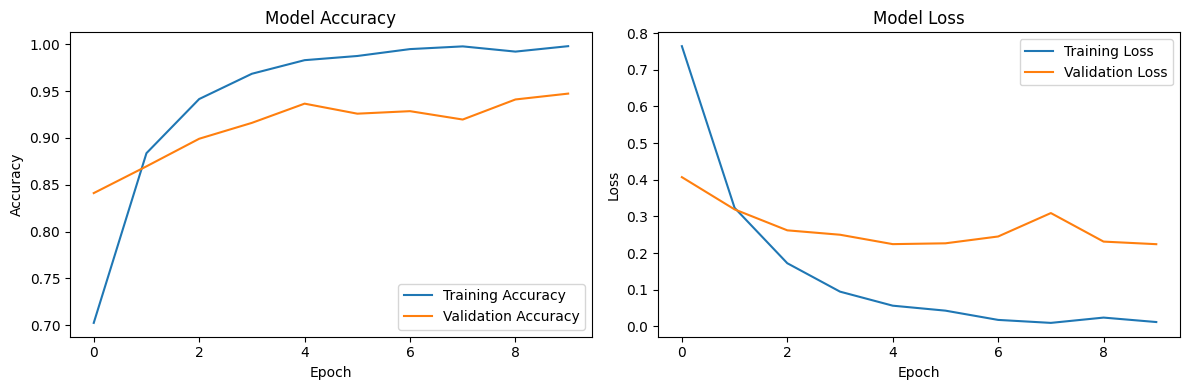

In [14]:
# Plot training & validation accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## TEST THE TUMOR DETECTOR

TESTING TUMOR DETECTOR

Testing on Glioma Tumor Image:


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


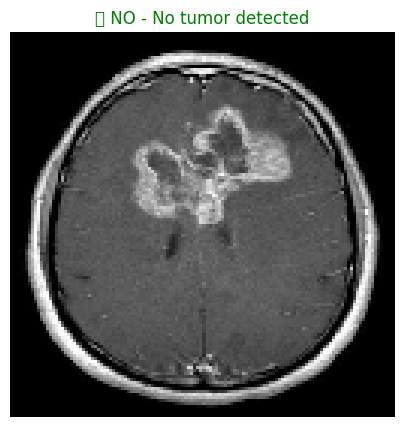

NO - No tumor detected

Testing on Notumor Image:


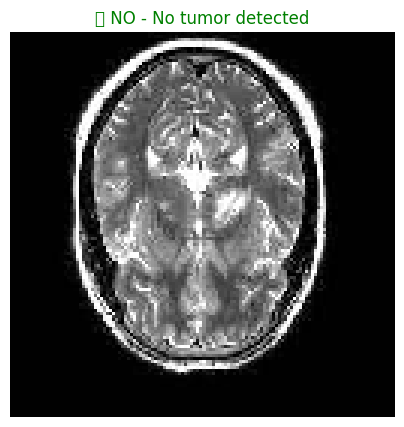

NO - No tumor detected


In [37]:
print("TESTING TUMOR DETECTOR")


# Test on a glioma tumor image
test_image_glioma = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/glioma/Te-gl_1.jpg'

if os.path.exists(test_image_glioma):
    print("\nTesting on Glioma Tumor Image:")
    predict_and_show(test_image_glioma)
else:
    print(f"\nFile not found: {test_image_glioma}")

# Test on a notumor image
test_image_notumor = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/notumor/Te-no_10.jpg'

if os.path.exists(test_image_notumor):
    print("\nTesting on Notumor Image:")
    predict_and_show(test_image_notumor)
else:
    print(f"\nFile not found: {test_image_notumor}")

## Confusion matrix and Classification report

In [35]:
from sklearn.metrics import confusion_matrix, classification_report

# Get class names
class_names = train_ds.class_names

# Collect predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# # Classification Report
# print("\nClassification Report:")
# print(classification_report(y_true, y_pred, target_names=class_names))

Confusion Matrix:
[[299  42  51   8]
 [ 33 330  26  11]
 [  0   1 399   0]
 [  6  23   0 371]]
